# Lab 2: Density Estimation

Import and explore the data, implements python functions to (i) estimate density distributions from the data, and (ii) predict classes using the estimated density distributions. Submit this notebook to eclass with the name "lab1_123456.ipynb" and replace "123456" by the ID you used for the first lab.

Import the libraries you will use for this lab:

In [2]:
import numpy as np
import pandas as pd
import scipy.io
from sklearn import model_selection
import matplotlib.pyplot as plt

Import the data in "DensitiEstimationDataset.mat" and "GlassClassification.csv" datasets

In [3]:
mat = scipy.io.loadmat('DensityEstimationDataset.mat') 
print("Keys: ", mat.keys())
print("Size is: ", mat['DensityEstimationDataset'].shape)


mat = mat['DensityEstimationDataset']
glass = pd.read_csv('GlassClassification.csv')
print("\n\n")
print("Glass dataset shape: ", glass.shape)
print("Glass dataset columns: ", glass.columns)

X1 = mat[:, :2]   #datapoints from DensityEstimationDataset
y1 = mat[:, 2]  #classes from DensityEstimationDataset
X2 = glass.iloc[:, :-1].values  #datapoints from Glass dataset
y2 = glass.iloc[:, -1].values  #classes from Glass dataset

Keys:  dict_keys(['__header__', '__version__', '__globals__', 'DensityEstimationDataset', 'R0', 'R1', 'R2', 'Sigma0', 'Sigma1', 'Sigma2', 'data0', 'data1', 'data2', 'mu0', 'mu1', 'mu2', 'size0', 'size1', 'size2', 't0', 't1', 't2'])
Size is:  (12000, 3)



Glass dataset shape:  (197, 5)
Glass dataset columns:  Index(['Sodium', 'Aluminium', 'Silicon', 'Calcium', 'Class'], dtype='object')


Check the classes for each of the datasets

In [4]:
print("=========================================================================")
print(np.unique(y1))
print("=========================================================================")
print(np.unique(y2))
print("=========================================================================")

[0. 1. 2.]
[1 2]


Divide your dataset into training and testing sets

In [5]:
X_train1, X_test1, y_train1, y_test1 = model_selection.train_test_split(X1, y1, test_size=0.3)
X_train2, X_test2, y_train2, y_test2 = model_selection.train_test_split(X2, y2, test_size=0.3)

print("=========================================================================")
print("X_train1 shape: ", X_train1.shape)
print("y_train1 shape: ", y_train1.shape)
print("X_test1 shape: ", X_test1.shape)
print("y_test1 shape: ", y_test1.shape)
print("=========================================================================")
print("X_train2 shape: ", X_train2.shape)
print("y_train2 shape: ", y_train2.shape)
print("X_test2 shape: ", X_test2.shape)
print("y_test2 shape: ", y_test2.shape)
print("=========================================================================")

X_train1 shape:  (8400, 2)
y_train1 shape:  (8400,)
X_test1 shape:  (3600, 2)
y_test1 shape:  (3600,)
X_train2 shape:  (137, 4)
y_train2 shape:  (137,)
X_test2 shape:  (60, 4)
y_test2 shape:  (60,)


Create a function that estimate gaussian distributions for each class. Think that the output your function generates needs to be useful for you to predict for new points.

In [6]:
def GDE(Xtrain,ytrain):
    classes = np.unique(ytrain)
    estimates = {}

    for c in classes:
        Xc = Xtrain[ytrain == c]
        #print(Xc)

        # Calcular la media (mu) y la matriz de covarianza (sigma)
        mu = np.mean(Xc, axis=0)
        sigma = np.cov(Xc.T, bias=True)
        prior = len(Xc) / len(Xtrain)

        # Guardar en el diccionario
        estimates[c] = {
            'mu': mu,
            'sigma': sigma,
            'prior': prior
        }

    return estimates



Analize the output of your function and built another one that can use that output to predict the class for a new set of points.

In [7]:
def MGaussian(X,mu,cov):
    _, d = X.shape
    cov_inv = np.linalg.inv(cov)
    cov_det = np.linalg.det(cov)
    norm_const = 1 / np.sqrt((2 * np.pi) ** d * cov_det)

    diffs = X - mu 
    exponents = -0.5 * np.sum(diffs @ cov_inv * diffs, axis=1)
    probs = norm_const * np.exp(exponents)

    #return #pdf(X) where the pdf is a multivariate gaussian with mean mu and convariance cov
    return probs  # Vector de tamaño (n,)

def predG(model,Xtest):
    #'model' is the output of GDE function
    #Xtest is a matrix, your function should predict classes for each row
    n = len(Xtest)
    key_classes =  list(model.keys())
    score_probs = np.zeros((n, len(key_classes)))

    for i, key in enumerate(key_classes):
        mu = model[key]['mu']
        sigma = model[key]['sigma']
        prior = model[key]['prior']
        probs = MGaussian(Xtest, mu, sigma)

        score_probs[:, i] = probs
    print("Shape of score_probs: ", score_probs.shape)
    #print("score_probs", score_probs)
    predictions = np.argmax(score_probs, axis=1)
    return predictions

In [8]:
## GDE is the model
model = GDE(X_train1, y_train1)

## Now, we can predict the classes of the test set
predictions = predG(model, X_test1)
print("=========================================================================")
print("Predictions: ", predictions)
print("Size of predictions: ", len(predictions))   
print("=========================================================================")

Shape of score_probs:  (3600, 3)
Predictions:  [2 1 0 ... 0 1 2]
Size of predictions:  3600


Create a function that predicts the class of a point using the histogram of the points in the training set. This function does not "learn" a model, is directly a predictor of the point class.

In [9]:
# acontecer lo que pasa en un bin en especifico
def predH(Xtrain,ytrain,point,nbins):
    #print("point: ", point)
    #print("Shape of Xtrain: ", Xtrain.shape)
    #print("Shape of ytrain: ", ytrain.shape)
    min_value = np.min(Xtrain, axis=0)
    max_value = np.max(Xtrain, axis=0)

    ### calculate size of each bin
    bin_size = (max_value - min_value) / nbins
    #print("bin_size: ", bin_size)
    bin_index = np.floor((point - min_value) / bin_size).astype(int)
    bin_index = np.clip(bin_index, 0, nbins - 1)
    #print(bin_index)

    ### calculate the bin range train
    train_bin_index = np.floor((Xtrain - min_value) / bin_size).astype(int)
    train_bin_index = np.clip(train_bin_index, 0, nbins - 1)

    ### find witch points are in the same bin
    points_in_bin = np.all(train_bin_index == bin_index, axis=1)
    #print("point closest to bin: ", points_in_bin)
    classs_in_bin = ytrain[points_in_bin]
    #print(classs_in_bin)

    ### if "class in bin" is empty return the hightest class
    if (len(classs_in_bin) == 0):
        default_class = np.bincount(ytrain).argmax()
        return default_class

    values, counts = np.unique(classs_in_bin, return_counts=True)
    out = values[np.argmax(counts)]

    return out 

point = np.array([12.5, 2.2, 74.24, 6.19])
pred = predH(X_train2, y_train2, point, nbins=2)
print("Clase predicha:", pred)

Clase predicha: 1


Build an accuracy function (you can use the one you built for the 1st lab). It should output the overall accuracy and the accuracy per class. 

In [10]:
def acc(pred,target):
    total_acc = np.mean(pred == target)
    unique_classes = np.unique(target)
    class_acc = []

    for c in unique_classes:
        index = (target == c)
        class_acc.append(np.mean(pred[index] == c))

    return total_acc, *class_acc

Build a loss matrix function, the output should clearly express the meaning of the matrix to the user. 

In [11]:
# depende del numero de clases
def loss_matrix(pred,y):
    y = y.astype(int)
    
    # Normalize classes
    min_class = min(np.min(y), np.min(pred))
    pred = pred - min_class
    y = y - min_class
    
    n_classes = len(np.unique(y))
    matrix = np.zeros((n_classes, n_classes))

    #if (np.sort(np.unique(y)) == np.sort(np.unique(pred))).all:
    #    print("equals")

    for i in range(len(y)):
        matrix[int(y[i])][pred[i]] += 1

    return matrix

Use your functions to predict and evaluate for the DensityEstimationDataset below.

In [12]:
model_density = GDE(X_train1, y_train1)
pred_density = predG(model_density, X_test1)

print("Evaluation for DensityEstimationDataset")
acc_total, *acc_classes = acc(pred_density, y_test1)
print(*acc_classes)
print("Accuracy total: ", acc_total)
for i, acc_class in enumerate(acc_classes):
    print(f"Accuracy class {i}: ", acc_class)

loss_matrix_result = loss_matrix(pred_density, y_test1)
print("loss matrix: \n", loss_matrix_result)

Shape of score_probs:  (3600, 3)
Evaluation for DensityEstimationDataset
0.9491525423728814 0.9290633608815427 0.9231987331749802
Accuracy total:  0.9319444444444445
Accuracy class 0:  0.9491525423728814
Accuracy class 1:  0.9290633608815427
Accuracy class 2:  0.9231987331749802
loss matrix: 
 [[ 840.    0.   45.]
 [   0. 1349.  103.]
 [  58.   39. 1166.]]


Use your functions to predict and evaluate for the Glass Classification dataset here

In [13]:
# point per point
pred_glass = []
for point in X_test2:
    pred_point = predH(X_train2, y_train2, point, nbins=2)
    pred_glass.append(pred_point)

pred_glass = np.array(pred_glass) 

print("Evaluation for Glass Classification")
acc_total2, *acc_classes2 = acc(pred_glass, y_test2)
print("Accuracy total: ", acc_total2)
for i, acc_class2 in enumerate(acc_classes2):
    print(f"Accuracy class {i}: ", acc_classes2)

loss_matrix_result2 = loss_matrix(pred_glass, y_test2)
print("loss matrix: \n", loss_matrix_result2)

Evaluation for Glass Classification
Accuracy total:  0.8333333333333334
Accuracy class 0:  [np.float64(0.9302325581395349), np.float64(0.5882352941176471)]
Accuracy class 1:  [np.float64(0.9302325581395349), np.float64(0.5882352941176471)]
loss matrix: 
 [[40.  3.]
 [ 7. 10.]]


Think of proper plots to show your results for each dataset. All plots should contain labels and titles describing the results.

# DensityEstimationDataset

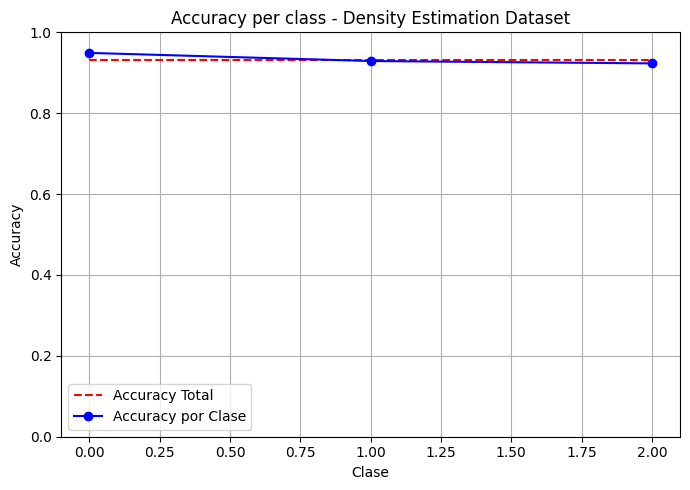

In [14]:
classes = np.arange(len(acc_classes))
plt.figure(figsize=(7,5))
plt.plot(classes, [acc_total]*len(classes), label='Accuracy Total', linestyle='--', color='red')
plt.plot(classes, acc_classes, label='Accuracy por Clase', marker='o', color='blue')
plt.title("Accuracy per class - Density Estimation Dataset")
plt.xlabel("Clase")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

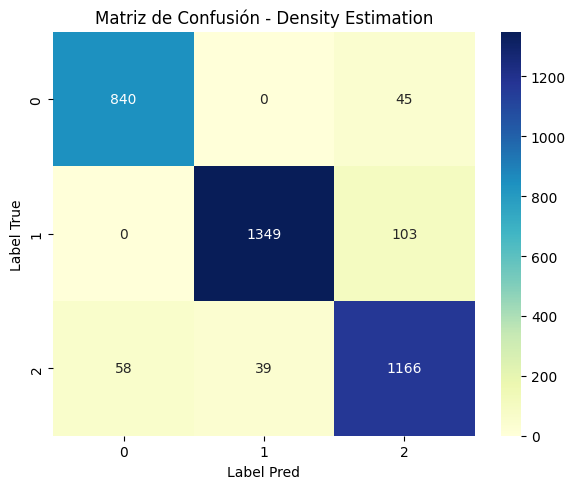

In [15]:
#%pip install seaborn
import seaborn as sns
plt.figure(figsize=(6,5))
sns.heatmap(loss_matrix_result, annot=True, fmt='.0f', cmap="YlGnBu")
plt.title("Matriz de Confusión - Density Estimation")
plt.xlabel("Label Pred")
plt.ylabel("Label True")
plt.tight_layout()
plt.show()


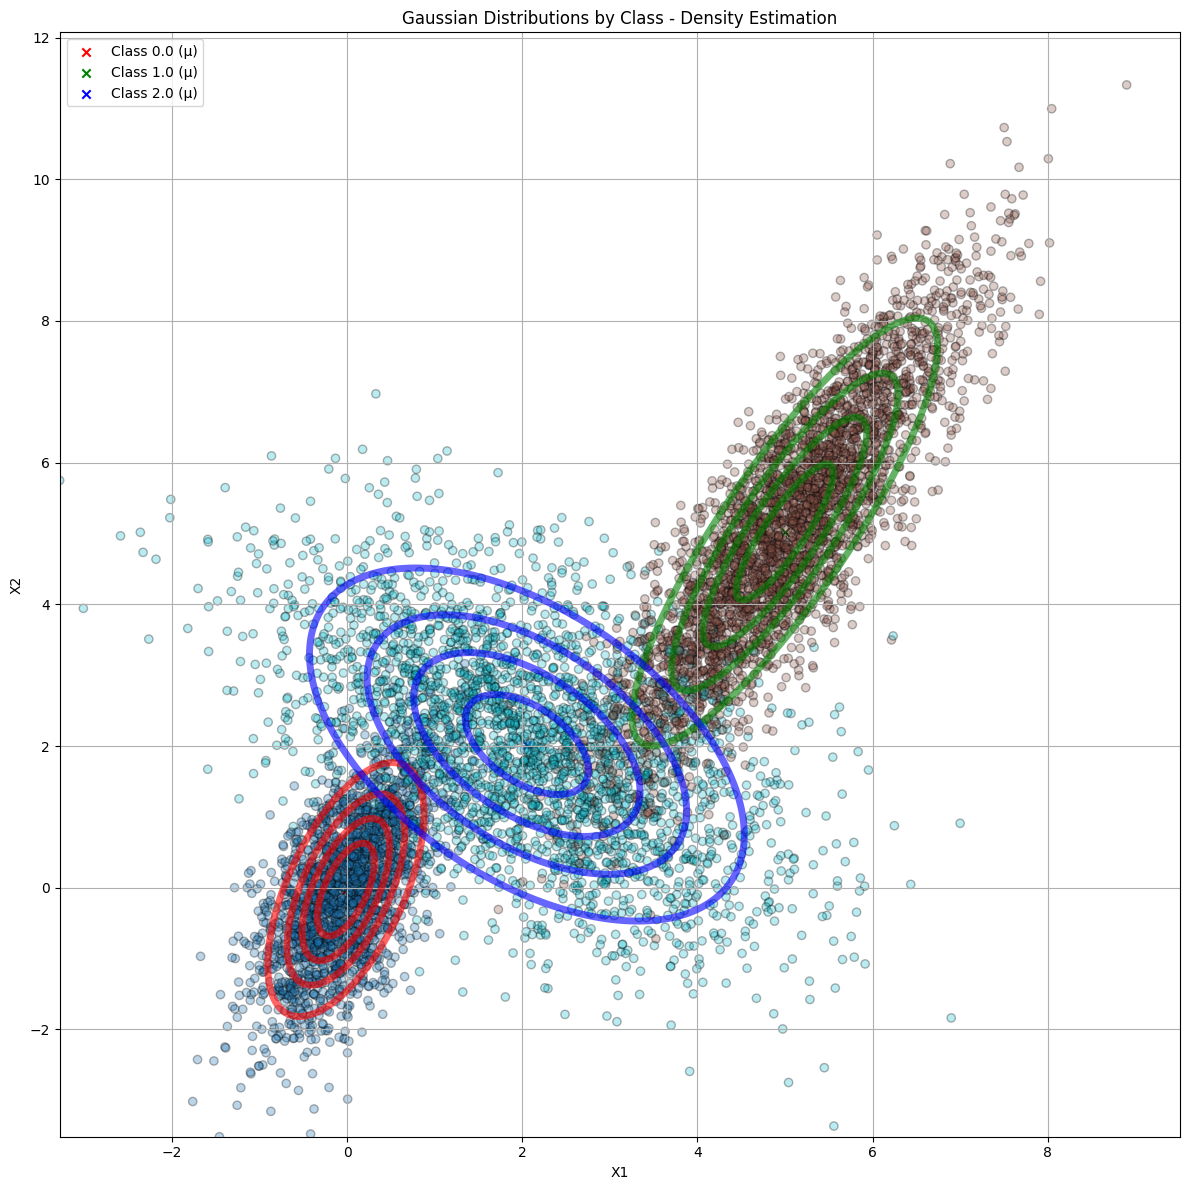

In [16]:
from scipy.stats import multivariate_normal

x, y = np.mgrid[
    X_train1[:,0].min():X_train1[:,0].max():.03,
    X_train1[:,1].min():X_train1[:,1].max():.03
]
pos = np.dstack((x, y))

plt.figure(figsize=(12,12))
colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k'] 

for i, (label, params) in enumerate(model_density.items()):
    mu = params['mu']
    sigma = params['sigma']
    
    rv = multivariate_normal(mean=mu, cov=sigma)
    plt.contour(x, y, rv.pdf(pos), levels=5, colors=colors[i % len(colors)], alpha=0.6, linewidths=5)
    plt.scatter(mu[0], mu[1], marker='x', color=colors[i % len(colors)], label=f'Class {label} (µ)')

plt.scatter(X_train1[:,0], X_train1[:,1], c=y_train1, cmap='tab10', alpha=0.3, edgecolor='k')
plt.title("Gaussian Distributions by Class - Density Estimation")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Glass Classification

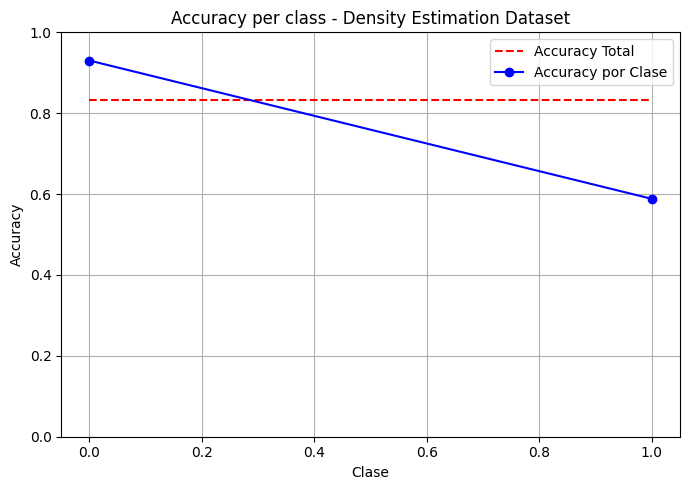

In [17]:
classes2 = np.arange(len(acc_classes2))
plt.figure(figsize=(7,5))
plt.plot(classes2, [acc_total2]*len(classes2), label='Accuracy Total', linestyle='--', color='red')
plt.plot(classes2, acc_classes2, label='Accuracy por Clase', marker='o', color='blue')
plt.title("Accuracy per class - Density Estimation Dataset")
plt.xlabel("Clase")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

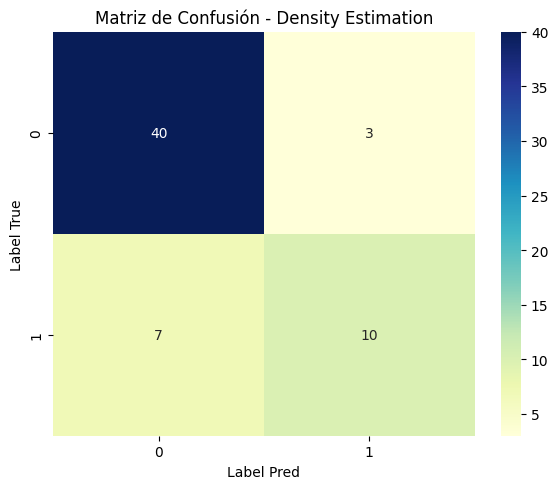

In [18]:
#%pip install seaborn
import seaborn as sns
plt.figure(figsize=(6,5))
sns.heatmap(loss_matrix_result2, annot=True, fmt='.0f', cmap="YlGnBu")
plt.title("Matriz de Confusión - Density Estimation")
plt.xlabel("Label Pred")
plt.ylabel("Label True")
plt.tight_layout()
plt.show()


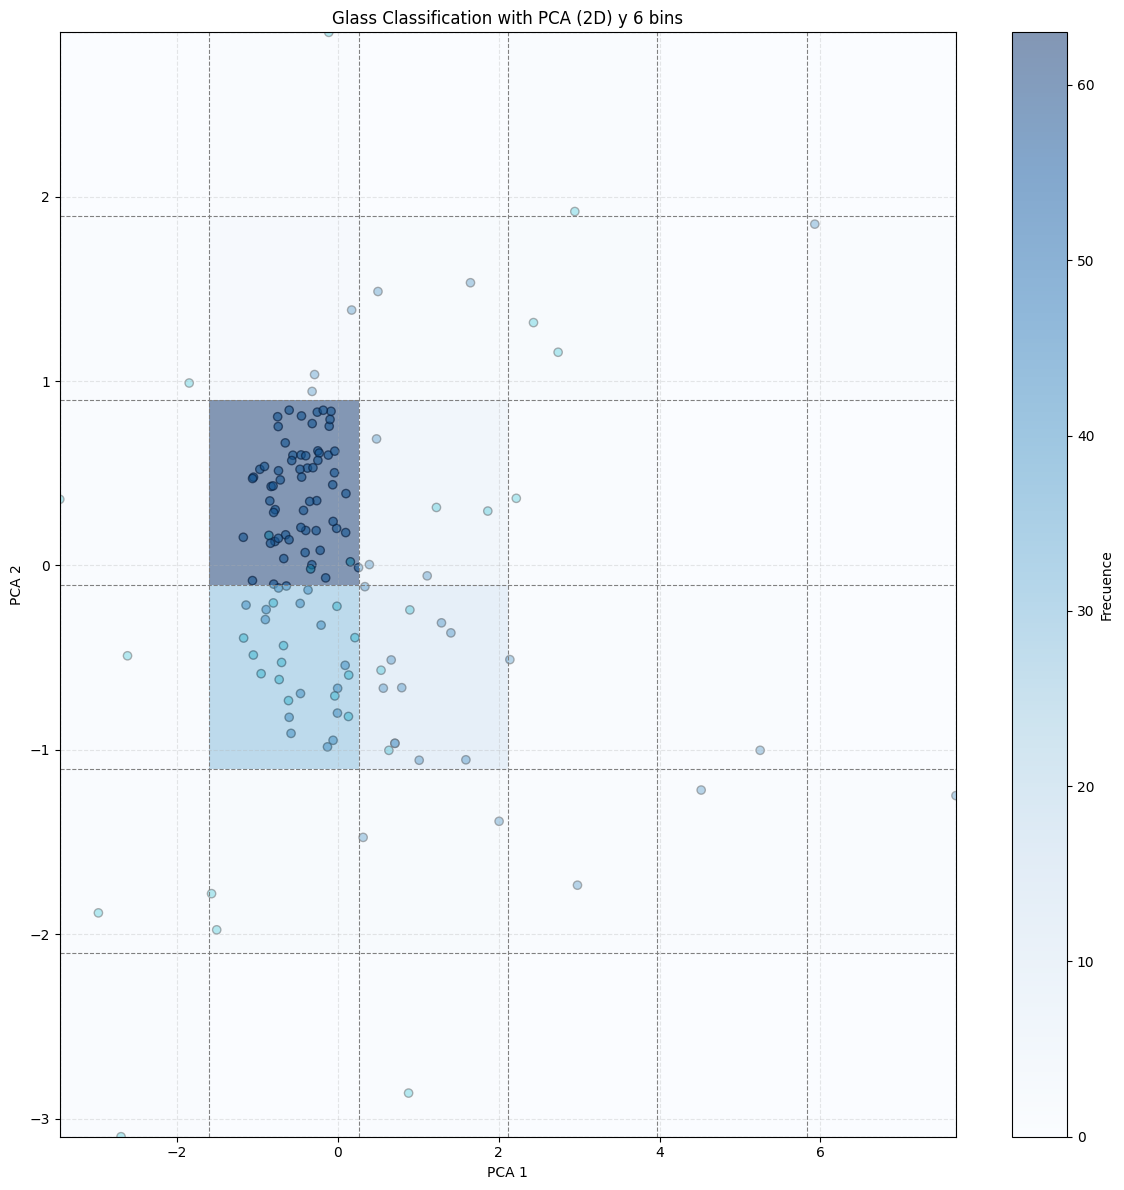

In [19]:
from sklearn.decomposition import PCA

pca_2d = PCA(n_components=2)
X_train2_pca = pca_2d.fit_transform(X_train2)
nbins = 6

min_val = np.min(X_train2_pca, axis=0)
max_val = np.max(X_train2_pca, axis=0)
bin_size = (max_val - min_val) / nbins

plt.figure(figsize=(12,12))

for i in range(nbins + 1):
    plt.axvline(min_val[0] + i * bin_size[0], color='gray', linestyle='--', linewidth=0.8)
    plt.axhline(min_val[1] + i * bin_size[1], color='gray', linestyle='--', linewidth=0.8)

plt.scatter(X_train2_pca[:,0], X_train2_pca[:,1], c=y_train2, cmap='tab10', edgecolor='k', alpha=0.6)
plt.hist2d(X_train2_pca[:,0], X_train2_pca[:,1], bins=nbins, cmap='Blues', alpha=0.5)

# Títulos y etiquetas
plt.title(f"Glass Classification with PCA (2D) y {nbins} bins")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.colorbar(label='Frecuence')
plt.show()


Experiment with different number of bins for your histogram-based predictor. Plot this experiment to show how the performance behave for the different values.

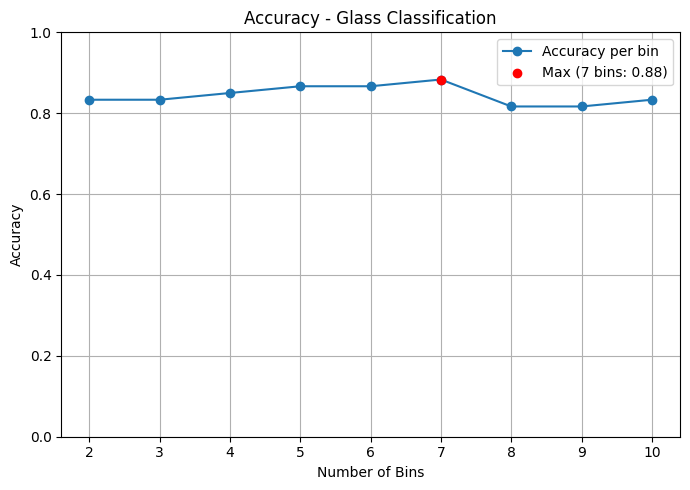

In [20]:

acc_by_bins = []
bin_range = range(2, 11)

for b in bin_range:
    pred = [predH(X_train2, y_train2, p, nbins=b) for p in X_test2]
    acc_total, *_ = acc(np.array(pred), y_test2)
    acc_by_bins.append(acc_total)

max_idx = np.argmax(acc_by_bins)
max_bin = list(bin_range)[max_idx]
max_acc = acc_by_bins[max_idx]

plt.figure(figsize=(7,5))
plt.plot(list(bin_range), acc_by_bins, marker='o', label="Accuracy per bin")
plt.scatter([max_bin], [max_acc], color='red', label=f'Max ({max_bin} bins: {max_acc:.2f})', zorder=5)
plt.title("Accuracy - Glass Classification")
plt.xlabel("Number of Bins")
plt.ylabel("Accuracy")
plt.grid(True)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()